In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_parquet("../processed/final_master_dataset.parquet")

In [3]:
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns}")
print(df.dtypes)

Shape: (5598786, 59)
Columns: Index(['mbid', 'bpm', 'bpm_histogram_first_peak_bpm_mean',
       'bpm_histogram_first_peak_bpm_median',
       'bpm_histogram_second_peak_bpm_mean',
       'bpm_histogram_second_peak_bpm_median', 'danceability', 'onset_rate',
       'average_loudness', 'dynamic_complexity', 'mfcc_zero_mean',
       'tuning_frequency', 'tuning_equal_tempered_deviation', 'key_key',
       'key_scale', 'mood_happy_prob', 'mood_aggressive_prob', 'mood_happy',
       'mood_sad', 'mood_relaxed', 'mood_aggressive', 'mood_acoustic',
       'mood_electronic', 'mood_party', 'voice_gender', 'timbre',
       'tonal_atonal', 'voice_instrumental', 'artist_mbid',
       'artist_credit_name', 'release_mbid', 'release_name', 'recording_name',
       'combined_lookup', 'status', 'language', 'script', 'quality',
       'release_year', 'release_month', 'release_day', 'artist_name',
       'artist_type', 'artist_country', 'gender', 'artist_geo_entity',
       'artist_begin_year', 'artist_end_

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5598786 entries, 0 to 5598785
Data columns (total 59 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   mbid                                  str    
 1   bpm                                   float64
 2   bpm_histogram_first_peak_bpm_mean     float64
 3   bpm_histogram_first_peak_bpm_median   float64
 4   bpm_histogram_second_peak_bpm_mean    float64
 5   bpm_histogram_second_peak_bpm_median  float64
 6   danceability                          float64
 7   onset_rate                            float64
 8   average_loudness                      float64
 9   dynamic_complexity                    float64
 10  mfcc_zero_mean                        float64
 11  tuning_frequency                      float64
 12  tuning_equal_tempered_deviation       float64
 13  key_key                               str    
 14  key_scale                             str    
 15  mood_happy_prob           

Understanding the features

* mbid: musicbrainz id
* bpm: beats per minute
* bpm_histogram_first_peak_bpm_mean  : (for rhythm) average tempo (beats per minute) of the most prominent, dominant rhythm found in a song    
* bpm_histogram_first_peak_bpm_median  : median tempo of the most dominant rhythmic pulse in the song
* bpm_histogram_second_peak_bpm_mean  : average tempo of second most dominate rhythm in song. 
* bpm_histogram_second_peak_bpm_median  median tempo of the second most dominnat rhythmic pulse
* dancebility: the danceability value. Normal values range from 0 to ~3. The higher, the more danceable.
* onset_rate: average number of note attacks or sonic events detected per second in a track (onset is beginning of a sound or note where volumne sharply spikes) - measures rhythmic density or busyness of music
* average loudness: dynamic range descriptor. It rescales average loudness, computed on 2sec windows with 1 sec overlap, into the [0,1] interval. The value of 0 corresponds to signals with large dynamic range, 1 corresponds to signal with little dynamic range.
* dynamic_complexity: dynamic complexity computed on 2sec windows with 1sec overlap.
* mfcc_zero_mean - average valeu of hte very first mel frequency cepstral coeffciinet across the track - overall loudness footprint and basic timbral texture
* tuning_frequency: estimated tuning frequency [Hz]. 
* tuning_equal_tempered_deviation: measure of the deviation of HPCP local maxima with respect to equal-tempered bins
* key: key
* key_scale: major minor, etc
* mood_ features: the probability or binary of mood of song
* voice_gender
* timbre:
* tonal_atonal                          str    
* voice_instrumental                    str    
* artist_mbid                           str    
* artist_credit_name                    str    
* release_mbid                          str    
* release_name                          str    
* recording_name                        str    
* combined_lookup                       str    
* status                                str    
* language                              float64
* script                                float64
* quality                               float64
* release_year                          float64
* release_month                         float64
* release_day                           float64
* artist_name                           str    
* artist_type                           float64
* artist_country                        str    
* gender                                str    
* artist_geo_entity                     float64
* artist_begin_year                     str    
* artist_end_year                       float64
* ended                                 str    
* release_group_top_genre               str    
* release_group_top_genre_votes         float64
* release_group_all_genres              str    
* artist_top_genre                      str    
* artist_top_genre_votes                float64
* artist_all_genres                     str    
* recording_top_genre                   str    
* recording_top_genre_votes             float64
* recording_all_genres                  str    
* genre                                 str 

 gender: 1 → Male
2 → Female
3 → Other
4 → Not applicable
5 → Non-binary



In [24]:
df.isnull().sum()

mbid                                          0
bpm                                           0
bpm_histogram_first_peak_bpm_mean             0
bpm_histogram_first_peak_bpm_median           0
bpm_histogram_second_peak_bpm_mean            0
bpm_histogram_second_peak_bpm_median          0
danceability                                  0
onset_rate                                    0
average_loudness                              0
dynamic_complexity                            0
mfcc_zero_mean                                0
tuning_frequency                              0
tuning_equal_tempered_deviation               0
key_key                                       0
key_scale                                     0
mood_happy_prob                               0
mood_aggressive_prob                          0
mood_happy                                    0
mood_sad                                      0
mood_relaxed                                  0
mood_aggressive                         

In [25]:
df['quality'].value_counts()

quality
-1.0    5569027
 2.0      12990
 1.0       6383
 0.0       4951
Name: count, dtype: int64

In [26]:
df['status'].value_counts()

status
1     5380246
3       61967
2       49676
4        8374
5        5246
38        152
6         110
Name: count, dtype: int64

In [27]:
df['script'].value_counts()

script
28.0     5079133
85.0      149229
160.0      32888
31.0       30171
94.0        6568
93.0        3311
43.0        3053
22.0        2511
101.0       1250
11.0        1184
111.0        960
92.0         521
18.0         510
84.0         412
65.0         325
112.0        239
36.0          54
50.0          49
83.0          33
87.0          28
26.0          21
53.0          20
100.0         15
64.0          15
35.0           9
63.0           6
59.0           6
86.0           6
62.0           6
23.0           2
4.0            1
Name: count, dtype: int64

In [28]:
df['artist_credit_name'].value_counts()

artist_credit_name
[unknown]                                                                                 9657
sonnov                                                                                    4151
Jerry Goldsmith                                                                           3668
Ennio Morricone                                                                           3318
HasenChat Music                                                                           2279
                                                                                          ... 
MHB Crew                                                                                     1
Amp Fiddler feat. Neco Redd & Ideeyah                                                        1
Grigori Zhislin, Polish Radio and Television Symphony Orchestra Krakow, Szymon Kawalla       1
Night Music                                                                                  1
The Blind Boys of Alabama with 

I want to predict genre based off audio features alone (without including bias such as artist_country, artist_name, release_year, etc) So I will drop the following columns

In [29]:
df['release_name'].value_counts()

release_name
Die kompletten Werke von Johann Sebastian Bach (Die Edition Bachakademie)    2232
II                                                                           2019
Live                                                                         1694
Greatest Hits                                                                1681
III                                                                          1595
                                                                             ... 
L'Été des Hits, Volume 3                                                        1
Everything to Me (Adventure club remix)                                         1
BZRK Records - Cr@zy Cutz 2 - Live Your Life Just Go BZRK!                      1
The Sensation of Sound: Pop Goes Classic, Volume 2                              1
This Is Ann Peebles & The Handwriting Is on the Wall                            1
Name: count, Length: 662341, dtype: int64

In [30]:
df['artist_name'].value_counts()

artist_name
[unknown]             10216
sonnov                 4151
Jerry Goldsmith        3668
Ennio Morricone        3352
John Williams          2439
                      ...  
The Jets Of Nights        1
A Hidden Trace            1
Orange Delight            1
MHB Crew                  1
Night Music               1
Name: count, Length: 348690, dtype: int64

In [31]:
df['combined_lookup'].value_counts()

combined_lookup
glowstonecircle                                                      1
nyimalugmonksnyuledrelwa                                             1
scorchedfieldsoffamine                                               1
ayreonmirrorofdreams                                                 1
bigladziltch                                                         1
                                                                    ..
evelynglenniealbanysymphonydavidalanmillerconjurermovementiiiskin    1
thechordetteshellomababy                                             1
vcrclassiquefallintallahassee                                        1
kenfordtotheleft                                                     1
denizakbulutarenalobby                                               1
Name: count, Length: 5598786, dtype: int64

In [32]:
df['status'].value_counts()

status
1     5380246
3       61967
2       49676
4        8374
5        5246
38        152
6         110
Name: count, dtype: int64

In [33]:
df['script'].value_counts()

script
28.0     5079133
85.0      149229
160.0      32888
31.0       30171
94.0        6568
93.0        3311
43.0        3053
22.0        2511
101.0       1250
11.0        1184
111.0        960
92.0         521
18.0         510
84.0         412
65.0         325
112.0        239
36.0          54
50.0          49
83.0          33
87.0          28
26.0          21
53.0          20
100.0         15
64.0          15
35.0           9
63.0           6
59.0           6
86.0           6
62.0           6
23.0           2
4.0            1
Name: count, dtype: int64

In [34]:
df['artist_type'].value_counts()

artist_type
1.0    2344908
2.0    2152473
3.0      28667
5.0      15758
4.0       5787
6.0       4943
Name: count, dtype: int64

In [35]:
df['artist_geo_entity'].value_counts()

artist_geo_entity
1.0    3408306
3.0     625312
2.0     135022
4.0      13611
5.0      13190
7.0       1328
6.0        970
Name: count, dtype: int64

In [4]:
cols_to_drop = [
    "artist_credit_name",
    "combined_lookup",
    "status",
    "script",
    "quality",
    "release_month",
    "release_day",
    "artist_type",
    "artist_geo_entity",
    "artist_begin_year",
    "artist_end_year",
    "ended",
    "release_group_top_genre",
    "release_group_top_genre_votes",
    "release_group_all_genres",
    "artist_top_genre",
    "artist_top_genre_votes",
    "artist_all_genres",
    "recording_top_genre",
    "recording_top_genre_votes",
    "recording_all_genres"
]

In [5]:
df.drop(columns = cols_to_drop, inplace = True)

In [6]:
df.isna().sum()

mbid                                          0
bpm                                           0
bpm_histogram_first_peak_bpm_mean             0
bpm_histogram_first_peak_bpm_median           0
bpm_histogram_second_peak_bpm_mean            0
bpm_histogram_second_peak_bpm_median          0
danceability                                  0
onset_rate                                    0
average_loudness                              0
dynamic_complexity                            0
mfcc_zero_mean                                0
tuning_frequency                              0
tuning_equal_tempered_deviation               0
key_key                                       0
key_scale                                     0
mood_happy_prob                               0
mood_aggressive_prob                          0
mood_happy                                    0
mood_sad                                      0
mood_relaxed                                  0
mood_aggressive                         

Since ~5M rows total, decide to just drop the NAs from genre

In [7]:
df.dropna(subset = ['genre'], inplace = True)

In [51]:
df.isna().sum()

mbid                                         0
bpm                                          0
bpm_histogram_first_peak_bpm_mean            0
bpm_histogram_first_peak_bpm_median          0
bpm_histogram_second_peak_bpm_mean           0
bpm_histogram_second_peak_bpm_median         0
danceability                                 0
onset_rate                                   0
average_loudness                             0
dynamic_complexity                           0
mfcc_zero_mean                               0
tuning_frequency                             0
tuning_equal_tempered_deviation              0
key_key                                      0
key_scale                                    0
mood_happy_prob                              0
mood_aggressive_prob                         0
mood_happy                                   0
mood_sad                                     0
mood_relaxed                                 0
mood_aggressive                              0
mood_acoustic

Decide I don't need artist_country or gender

In [8]:
df.drop(columns = ['artist_country', 'gender'], inplace = True)

Drop NA from artist_name

In [9]:
df.dropna(subset = ['artist_name'], inplace = True)

In [54]:
df.isna().sum()

mbid                                         0
bpm                                          0
bpm_histogram_first_peak_bpm_mean            0
bpm_histogram_first_peak_bpm_median          0
bpm_histogram_second_peak_bpm_mean           0
bpm_histogram_second_peak_bpm_median         0
danceability                                 0
onset_rate                                   0
average_loudness                             0
dynamic_complexity                           0
mfcc_zero_mean                               0
tuning_frequency                             0
tuning_equal_tempered_deviation              0
key_key                                      0
key_scale                                    0
mood_happy_prob                              0
mood_aggressive_prob                         0
mood_happy                                   0
mood_sad                                     0
mood_relaxed                                 0
mood_aggressive                              0
mood_acoustic

In [55]:
df.shape

(4223666, 36)

In [10]:
df.dropna(subset = ['artist_name'], inplace = True)

In [57]:
df.isna().sum()

mbid                                         0
bpm                                          0
bpm_histogram_first_peak_bpm_mean            0
bpm_histogram_first_peak_bpm_median          0
bpm_histogram_second_peak_bpm_mean           0
bpm_histogram_second_peak_bpm_median         0
danceability                                 0
onset_rate                                   0
average_loudness                             0
dynamic_complexity                           0
mfcc_zero_mean                               0
tuning_frequency                             0
tuning_equal_tempered_deviation              0
key_key                                      0
key_scale                                    0
mood_happy_prob                              0
mood_aggressive_prob                         0
mood_happy                                   0
mood_sad                                     0
mood_relaxed                                 0
mood_aggressive                              0
mood_acoustic

In [11]:
df.dropna(subset = ['language'], inplace = True)

In [59]:
df.isna().sum()

mbid                                        0
bpm                                         0
bpm_histogram_first_peak_bpm_mean           0
bpm_histogram_first_peak_bpm_median         0
bpm_histogram_second_peak_bpm_mean          0
bpm_histogram_second_peak_bpm_median        0
danceability                                0
onset_rate                                  0
average_loudness                            0
dynamic_complexity                          0
mfcc_zero_mean                              0
tuning_frequency                            0
tuning_equal_tempered_deviation             0
key_key                                     0
key_scale                                   0
mood_happy_prob                             0
mood_aggressive_prob                        0
mood_happy                                  0
mood_sad                                    0
mood_relaxed                                0
mood_aggressive                             0
mood_acoustic                     

In [12]:
df.dropna(subset = ['release_year'], inplace = True)

In [61]:
df.isna().sum()

mbid                                     0
bpm                                      0
bpm_histogram_first_peak_bpm_mean        0
bpm_histogram_first_peak_bpm_median      0
bpm_histogram_second_peak_bpm_mean       0
bpm_histogram_second_peak_bpm_median     0
danceability                             0
onset_rate                               0
average_loudness                         0
dynamic_complexity                       0
mfcc_zero_mean                           0
tuning_frequency                         0
tuning_equal_tempered_deviation          0
key_key                                  0
key_scale                                0
mood_happy_prob                          0
mood_aggressive_prob                     0
mood_happy                               0
mood_sad                                 0
mood_relaxed                             0
mood_aggressive                          0
mood_acoustic                            0
mood_electronic                          0
mood_party 

In [13]:
df.dropna(subset = ['release_name', 'recording_name'], inplace = True)

In [14]:
df.isna().sum()

mbid                                    0
bpm                                     0
bpm_histogram_first_peak_bpm_mean       0
bpm_histogram_first_peak_bpm_median     0
bpm_histogram_second_peak_bpm_mean      0
bpm_histogram_second_peak_bpm_median    0
danceability                            0
onset_rate                              0
average_loudness                        0
dynamic_complexity                      0
mfcc_zero_mean                          0
tuning_frequency                        0
tuning_equal_tempered_deviation         0
key_key                                 0
key_scale                               0
mood_happy_prob                         0
mood_aggressive_prob                    0
mood_happy                              0
mood_sad                                0
mood_relaxed                            0
mood_aggressive                         0
mood_acoustic                           0
mood_electronic                         0
mood_party                        

In [64]:
df.info()

<class 'pandas.DataFrame'>
Index: 3954438 entries, 2 to 5598785
Data columns (total 36 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   mbid                                  str    
 1   bpm                                   float64
 2   bpm_histogram_first_peak_bpm_mean     float64
 3   bpm_histogram_first_peak_bpm_median   float64
 4   bpm_histogram_second_peak_bpm_mean    float64
 5   bpm_histogram_second_peak_bpm_median  float64
 6   danceability                          float64
 7   onset_rate                            float64
 8   average_loudness                      float64
 9   dynamic_complexity                    float64
 10  mfcc_zero_mean                        float64
 11  tuning_frequency                      float64
 12  tuning_equal_tempered_deviation       float64
 13  key_key                               str    
 14  key_scale                             str    
 15  mood_happy_prob                

Get the numeric columns to plot and examine distribution

In [15]:
numeric_cols = [col for col in df.columns if df[col].dtype == 'float64']

In [16]:
numeric_cols

['bpm',
 'bpm_histogram_first_peak_bpm_mean',
 'bpm_histogram_first_peak_bpm_median',
 'bpm_histogram_second_peak_bpm_mean',
 'bpm_histogram_second_peak_bpm_median',
 'danceability',
 'onset_rate',
 'average_loudness',
 'dynamic_complexity',
 'mfcc_zero_mean',
 'tuning_frequency',
 'tuning_equal_tempered_deviation',
 'mood_happy_prob',
 'mood_aggressive_prob',
 'language',
 'release_year']

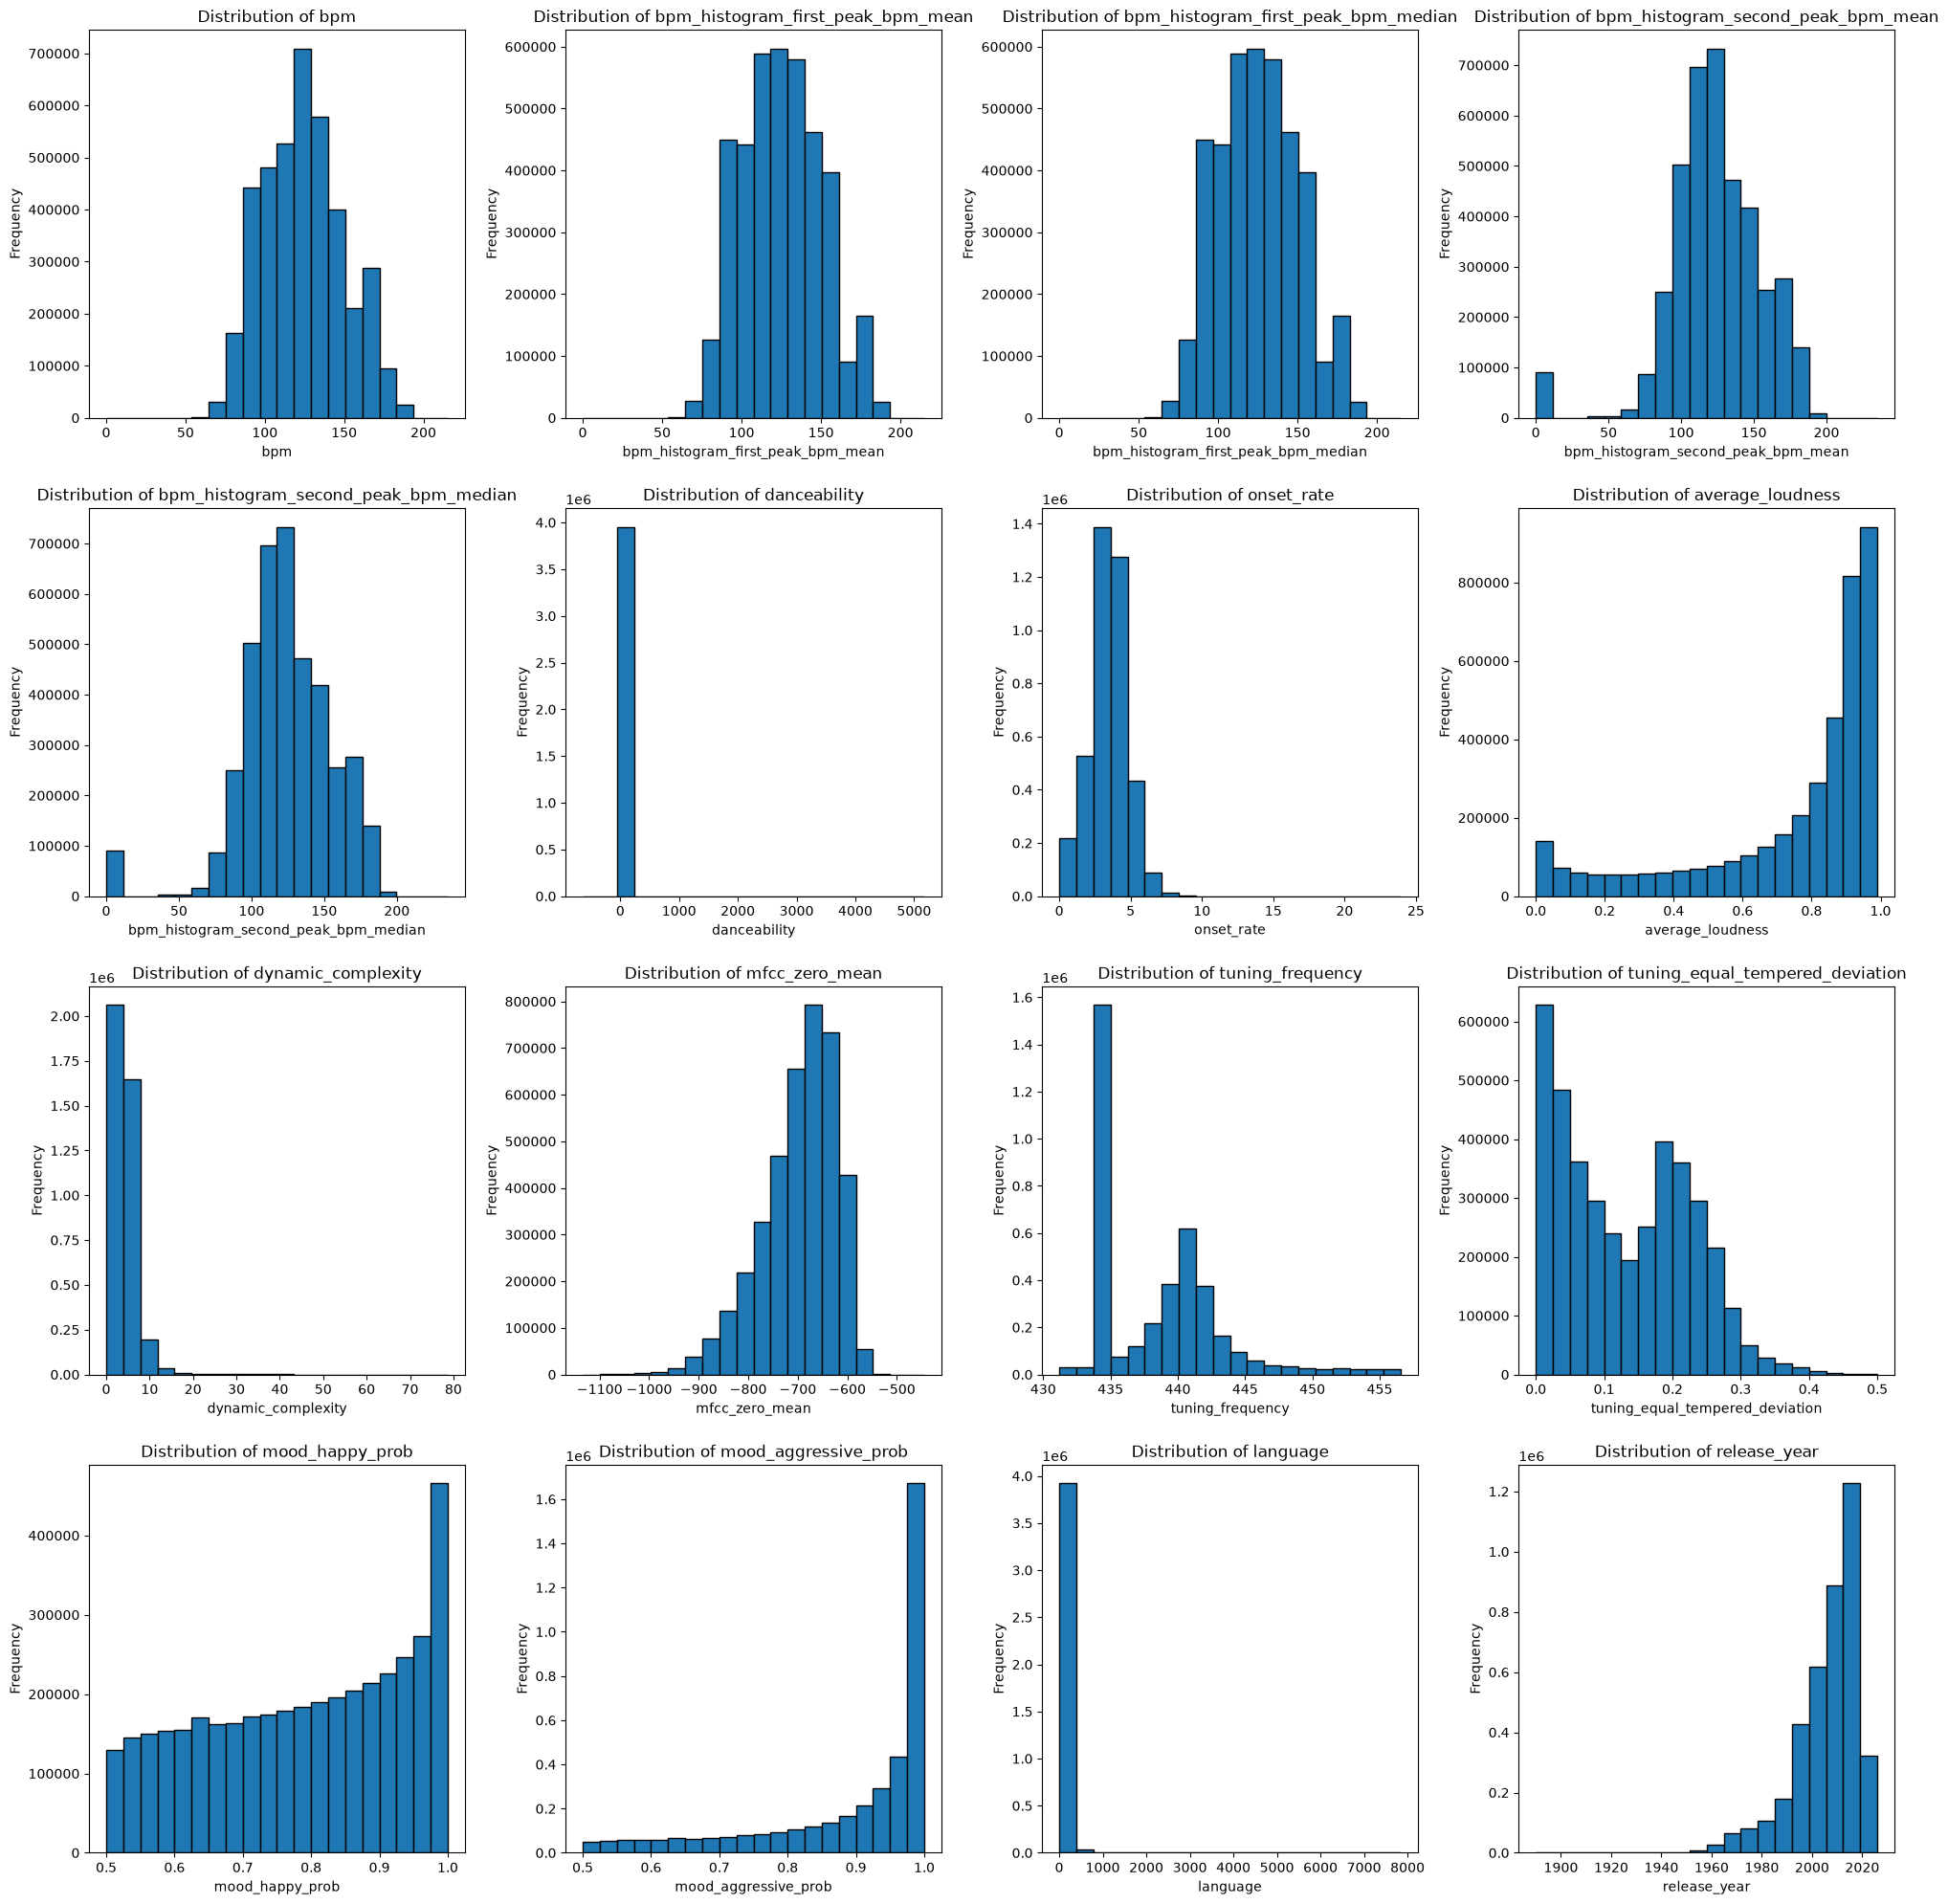

In [17]:
num_cols = len(numeric_cols)
n_cols = 4
n_rows = 4

fig, axes = plt.subplots(nrows=n_rows, ncols = n_cols, figsize=( 20,20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins = 20, edgecolor = 'black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


In [68]:
df.describe()

,bpm,bpm_histogram_first_peak_bpm_mean,bpm_histogram_first_peak_bpm_median,bpm_histogram_second_peak_bpm_mean,bpm_histogram_second_peak_bpm_median,danceability,onset_rate,average_loudness,dynamic_complexity,mfcc_zero_mean,tuning_frequency,tuning_equal_tempered_deviation,mood_happy_prob,mood_aggressive_prob,language,release_year
count,3.954438e+06,3.954438e+06,3.954438e+06,3.954438e+06,3.954438e+06,3.954438e+06,3.954438e+06,3.954438e+06,3.954438e+06,3.954438e+06,3.954438e+06,3.954438e+06,3.954438e+06,3.954438e+06,3.954438e+06,3.954438e+06
mean,1.239307e+02,1.243274e+02,1.243274e+02,1.241969e+02,1.241969e+02,1.157653e+00,3.448917e+00,7.468947e-01,4.318693e+00,-6.975129e+02,4.385110e+02,1.311734e-01,7.892896e-01,8.962783e-01,1.433332e+02,2.006104e+03
std,2.486521e+01,2.479541e+01,2.479541e+01,3.208231e+01,3.208231e+01,2.785797e+00,1.296963e+00,2.721518e-01,2.447836e+00,7.496401e+01,4.662524e+00,9.396910e-02,1.489480e-01,1.321462e-01,9.790187e+01,1.281309e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-6.389771e+02,0.000000e+00,2.084907e-08,0.000000e+00,-1.134098e+03,4.311939e+02,0.000000e+00,5.000000e-01,5.000000e-01,2.000000e+00,1.890000e+03
25%,1.046033e+02,1.050000e+02,1.050000e+02,1.080000e+02,1.080000e+02,1.008412e+00,2.675141e+00,6.559147e-01,2.856972e+00,-7.410999e+02,4.341931e+02,4.287556e-02,6.625005e-01,8.407795e-01,1.200000e+02,2.000000e+03
50%,1.230811e+02,1.230000e+02,1.230000e+02,1.230000e+02,1.230000e+02,1.119187e+00,3.473891e+00,8.710687e-01,3.846518e+00,-6.844657e+02,4.384777e+02,1.211671e-01,8.050318e-01,9.587911e-01,1.200000e+02,2.009000e+03
75%,1.400267e+02,1.400000e+02,1.400000e+02,1.440000e+02,1.440000e+02,1.254921e+00,4.271936e+00,9.390510e-01,5.138380e+00,-6.414361e+02,4.412726e+02,2.073975e-01,9.245929e-01,9.946893e-01,1.200000e+02,2.016000e+03
max,2.153320e+02,2.150000e+02,2.150000e+02,2.350000e+02,2.350000e+02,5.173636e+03,2.393871e+01,9.906840e-01,7.868979e+01,-4.445597e+02,4.565703e+02,5.000000e-01,1.000000e+00,1.000000e+00,7.845000e+03,2.026000e+03


Having 0 for bpm related features seems incorrect so will drop those

In [18]:
len(df[df['bpm_histogram_second_peak_bpm_mean'] < 20])

91215

In [19]:
df = df[df['bpm'] >= 20]
df = df[df['bpm_histogram_first_peak_bpm_mean'] >= 20]
df = df[df['bpm_histogram_first_peak_bpm_median'] >= 20]
df = df[df['bpm_histogram_second_peak_bpm_mean'] >= 20]
df = df[df['bpm_histogram_second_peak_bpm_median'] >= 20]

Based on the description, danceability should be between 0 and around 3: danceability (real) - the danceability value. Normal values range from 0 to ~3. The higher, the more danceable.

In [71]:
df['danceability'].describe()

count    3.863223e+06
mean     1.152968e+00
std      2.662321e+00
min     -3.040482e+01
25%      1.006620e+00
50%      1.116494e+00
75%      1.250208e+00
max      5.173636e+03
Name: danceability, dtype: float64

In [72]:
len(df[df['danceability'] < 0])

12

In [73]:
len(df[df['danceability'] > 3])

1331

In [20]:
df = df[df['danceability'].between(0, 3)]

MFCCs are:

log-scaled spectral features
often centered around negative values after processing
frequently mean-normalized (“zero_mean”) → shifts distribution below 0
not bounded to any fixed range

In [75]:
df['mfcc_zero_mean'].describe()

count    3.861880e+06
mean    -6.976361e+02
std      7.506332e+01
min     -1.134098e+03
25%     -7.415128e+02
50%     -6.845631e+02
75%     -6.413461e+02
max     -4.445597e+02
Name: mfcc_zero_mean, dtype: float64

In [76]:
df['tuning_equal_tempered_deviation'].describe()

count    3.861880e+06
mean     1.305563e-01
std      9.391275e-02
min      0.000000e+00
25%      4.238368e-02
50%      1.196778e-01
75%      2.070242e-01
max      5.000000e-01
Name: tuning_equal_tempered_deviation, dtype: float64

Check the distributions again

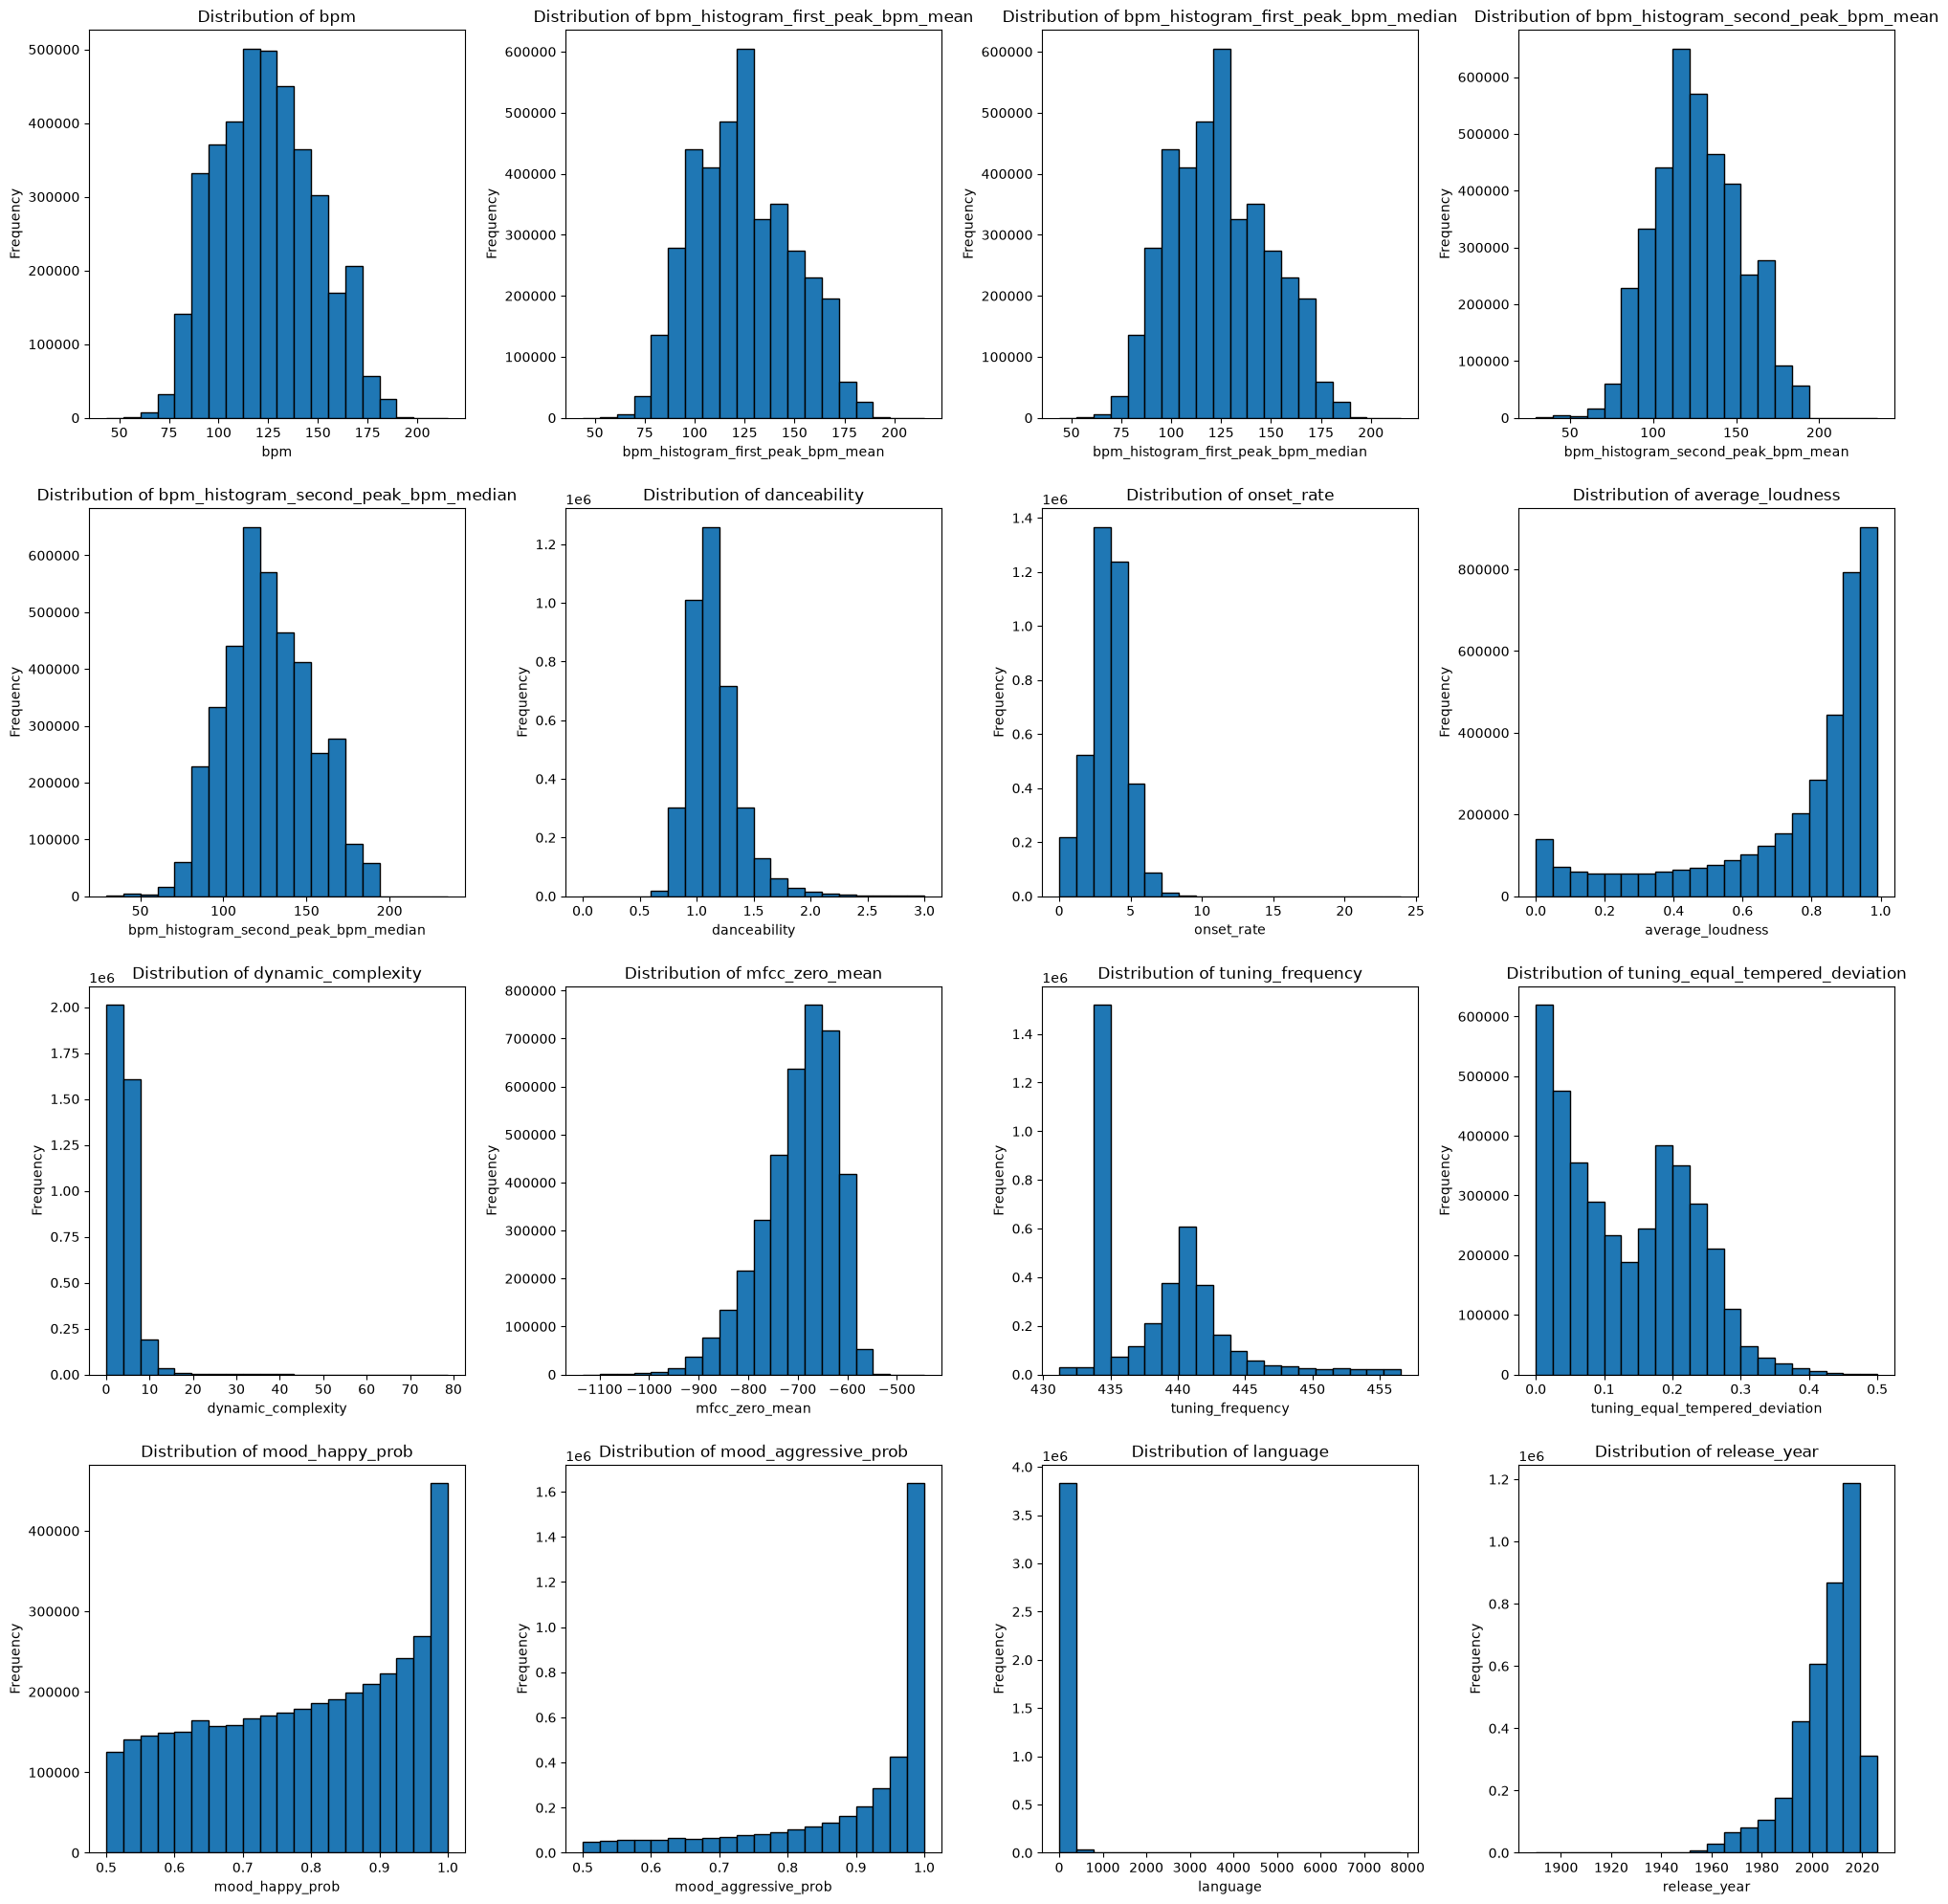

In [21]:
num_cols = len(numeric_cols)
n_cols = 4
n_rows = 4

fig, axes = plt.subplots(nrows=n_rows, ncols = n_cols, figsize=( 20,20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins = 20, edgecolor = 'black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


In [78]:
df.info()

<class 'pandas.DataFrame'>
Index: 4547837 entries, 2 to 5598785
Data columns (total 29 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   mbid                                  str    
 1   bpm                                   float64
 2   bpm_histogram_first_peak_bpm_mean     float64
 3   bpm_histogram_first_peak_bpm_median   float64
 4   bpm_histogram_second_peak_bpm_mean    float64
 5   bpm_histogram_second_peak_bpm_median  float64
 6   danceability                          float64
 7   onset_rate                            float64
 8   average_loudness                      float64
 9   dynamic_complexity                    float64
 10  mfcc_zero_mean                        float64
 11  tuning_frequency                      float64
 12  tuning_equal_tempered_deviation       float64
 13  key_key                               str    
 14  key_scale                             str    
 15  mood_happy_prob                

In [22]:
pd.set_option('display.max_rows', 500) 

In [24]:
# Run once if you haven't: !pip install itables
from itables import show

In [25]:
from IPython.display import display, HTML

# 1. Temporarily allow pandas to output all rows without cutting them off
with pd.option_context('display.max_rows', None):
    # 2. Convert your value counts to an HTML table string
    html_table = df['genre'].value_counts().to_frame().to_html()

# 3. Put that table inside a scrollable box (400 pixels high)
scroll_box = f"""
<div style="max-height: 400px; overflow-y: scroll; border: 1px solid #ccc; padding: 10px;">
    {html_table}
</div>
"""

# 4. Force Jupyter to render the scrollable box
display(HTML(scroll_box))

,count
genre,
rock,297405
electronic,294025
jazz,152434
pop,146554
hip hop,95175
classical,94249
experimental,79490
ambient,68339
folk,67472


In [26]:
genre_counts = df['genre'].value_counts().to_frame().reset_index()

In [27]:
genre_counts

,genre,count
0,rock,297405
1,electronic,294025
2,jazz,152434
3,pop,146554
4,hip hop,95175
...,...,...
7739,singeli,1
7740,the age of l.u.n.a,1
7741,swingbeat,1
7742,moldova,1


In [ ]:
############3 This below is done in genre eda, can remove

Do engineering of genre feature to create categories

In [29]:
from rapidfuzz import process

In [30]:
# Preprocess the genre column to clean invalid or missing entries
df["genre"] = df["genre"].fillna("").astype(str).str.strip()  # Handle missing/empty values and strip whitespaces

In [31]:
# Define main genres and their sub-genres
main_genres = {
    "Electronic": ["electronic", "edm", "techno", "house", "downtempo", "idm", "synthpop", "synth-wave", 
                   "electro", "ambient techno", "chillwave", "electronica", "vaporwave", "experimental electronic", 
                   "electro-acoustic", "progressive electronic", "chiptune", "gabber", "future funk"],
    "Rock": ["rock", "classic rock", "hard rock", "indie rock", "progressive rock", "psychedelic rock", 
             "alternative rock", "garage rock", "space rock", "grunge"],
    "Classical": ["classical", "modern classical", "baroque", "film composer", "composer", "symphony", 
                  "chamber music", "string quartet", "symphonic prog"],
    "Jazz": ["jazz", "bebop", "vocal jazz", "smooth jazz", "jazz fusion", "jazz-funk", "cool jazz", 
             "free jazz", "gypsy jazz", "fusion"],
    "Pop": ["pop", "indie pop", "pop soul", "pop rock", "synth-pop", "dance-pop", "psychedelic pop"],
    "Hip Hop": ["hip hop", "rap", "lo-fi hip hop", "gangsta rap", "underground hip hop", "pop rap", 
                "trap", "conscious hip hop"],
    "Experimental": ["experimental", "noise", "avant-garde", "sound art", "dungeon synth", "ambient experimental"],
    "Ambient": ["ambient", "dark ambient", "space ambient", "cinematic classical"],
    "Folk": ["folk", "indie folk", "folk pop", "folk rock", "neofolk", "folktronica"],
    "Punk": ["punk", "punk rock", "pop punk", "post-punk", "hardcore punk", "emo punk"],
    "Alternative Rock": ["alternative rock", "grunge", "noise rock", "shoegaze", "stoner rock", "experimental rock"],
    "Indie Rock": ["indie rock", "alternative indie", "dream pop", "math rock"],
    "Metal": ["metal", "doom metal", "death metal", "black metal", "thrash metal", "progressive metal"],
    "Country": ["country", "alt-country", "country pop", "country rock", "bluegrass", "americana"],
    "Soundtrack": ["soundtrack", "film", "anime", "vgm", "video game music", "musical", "cinematic"],
    "R&B": ["r&b", "soul and r&b", "contemporary r&b", "funk", "neo-soul"],
    "Reggae": ["reggae", "roots reggae", "dub", "dancehall", "ska"],
    "Blues": ["blues", "country blues", "blues rock", "soul blues", "electronic blues"],
    "Techno": ["techno", "minimal techno", "acid techno", "electro-techno"],
    "Heavy Metal": ["heavy metal", "viking metal", "doom metal", "progressive metal"],
    "Soul": ["soul", "neo soul", "southern soul"],
    "House": ["house", "progressive house", "electro house", "deep house", "tech house"],
    "Dance": ["dance", "dance pop", "dance rock", "freestyle"],
    "Easy Listening": ["easy listening", "lounge", "chillout"]
}

In [32]:
def map_main_genre(genre, main_genres):
    """
    Match genre to a main category using RapidFuzz for efficient string comparison.
    """
    for main_genre, subgenres in main_genres.items():
        match = process.extractOne(genre.lower(), subgenres, score_cutoff=85)
        if match:
            return main_genre  # Return main genre if match found
    return "Other"  # Default fallback

def map_sub_genre(genre, main_genres):
    """
    Returns subgenre directly if a valid match is identified, otherwise 'Other'.
    """
    for main_genre, subgenres in main_genres.items():
        match = process.extractOne(genre.lower(), subgenres, score_cutoff=85)
        if match:
            return match[0]  # Return matched subgenre
    return "Other"

def process_batch(df_batch, main_genres):
    """
    Processes a batch of rows and maps main_genre and sub_genre in parallel.
    """
    df_batch['main_genre'] = df_batch['genre'].apply(lambda g: map_main_genre(g, main_genres))
    df_batch['sub_genre'] = df_batch['genre'].apply(lambda g: map_sub_genre(g, main_genres))
    return df_batch

In [33]:
import os
# Configure batch size and directory for batch files
batch_size = 100000
output_dir = "processed_batches"  # Directory to store batch files
os.makedirs(output_dir, exist_ok=True)  # Create directory if it doesn't exist

# Process each batch and save to separate files
num_batches = len(df) // batch_size + 1
for batch_num in range(num_batches):
    print(f"Processing batch {batch_num + 1} / {num_batches}...")
    start_row = batch_num * batch_size
    end_row = min(start_row + batch_size, len(df))
    batch = df.iloc[start_row:end_row]
    
    # Process the batch
    result_batch = process_batch(batch, main_genres)
    
    # Save the batch as a separate file
    batch_file = os.path.join(output_dir, f"batch_{batch_num + 1}.csv")
    result_batch.to_csv(batch_file, index=False)
    print(f"Batch {batch_num + 1} saved to {batch_file}.")

print("Processing complete!")

Processing batch 1 / 39...
Batch 1 saved to processed_batches\batch_1.csv.
Processing batch 2 / 39...
Batch 2 saved to processed_batches\batch_2.csv.
Processing batch 3 / 39...
Batch 3 saved to processed_batches\batch_3.csv.
Processing batch 4 / 39...
Batch 4 saved to processed_batches\batch_4.csv.
Processing batch 5 / 39...
Batch 5 saved to processed_batches\batch_5.csv.
Processing batch 6 / 39...
Batch 6 saved to processed_batches\batch_6.csv.
Processing batch 7 / 39...
Batch 7 saved to processed_batches\batch_7.csv.
Processing batch 8 / 39...
Batch 8 saved to processed_batches\batch_8.csv.
Processing batch 9 / 39...
Batch 9 saved to processed_batches\batch_9.csv.
Processing batch 10 / 39...
Batch 10 saved to processed_batches\batch_10.csv.
Processing batch 11 / 39...
Batch 11 saved to processed_batches\batch_11.csv.
Processing batch 12 / 39...
Batch 12 saved to processed_batches\batch_12.csv.
Processing batch 13 / 39...
Batch 13 saved to processed_batches\batch_13.csv.
Processing ba

In [34]:
import glob

output_dir = "processed_batches"  # Directory to store batch files
os.makedirs(output_dir, exist_ok=True)  # Create directory if it doesn't exist

# Merge all batch files into a single DataFrame
batch_files = glob.glob(os.path.join(output_dir, "batch_*.csv"))
merged_df = pd.concat([pd.read_csv(batch_file) for batch_file in batch_files], ignore_index=True)

# Save the merged DataFrame
merged_df.to_csv("data/genre_processed_output.csv", index=False)
print("All batches merged into processed_output.csv.")

All batches merged into processed_output.csv.


In [35]:
df = pd.read_csv('data/genre_processed_output.csv')

In [36]:
df.shape

(3861880, 38)

In [37]:
df.isna().sum()

mbid                                    0
bpm                                     0
bpm_histogram_first_peak_bpm_mean       0
bpm_histogram_first_peak_bpm_median     0
bpm_histogram_second_peak_bpm_mean      0
bpm_histogram_second_peak_bpm_median    0
danceability                            0
onset_rate                              0
average_loudness                        0
dynamic_complexity                      0
mfcc_zero_mean                          0
tuning_frequency                        0
tuning_equal_tempered_deviation         0
key_key                                 0
key_scale                               0
mood_happy_prob                         0
mood_aggressive_prob                    0
mood_happy                              0
mood_sad                                0
mood_relaxed                            0
mood_aggressive                         0
mood_acoustic                           0
mood_electronic                         0
mood_party                        

In [7]:
df.head(3000000)

,mbid,bpm,bpm_histogram_first_peak_bpm_mean,bpm_histogram_first_peak_bpm_median,bpm_histogram_second_peak_bpm_mean,bpm_histogram_second_peak_bpm_median,danceability,onset_rate,average_loudness,dynamic_complexity,...,mood_acoustic,mood_electronic,mood_party,voice_gender,timbre,tonal_atonal,voice_instrumental,genre,main_genre,sub_genre
0,00000910-c0d0-4792-827c-9a31719161c3,132.114716,133.0,133.0,117.0,117.0,0.963751,2.697139,0.939739,2.026948,...,not_acoustic,not_electronic,not_party,female,dark,atonal,voice,death metal,Metal,death metal
1,000009a8-34f1-4c58-a8de-1d99809cd626,95.068558,96.0,96.0,88.0,88.0,1.064906,2.686261,0.687424,3.005937,...,acoustic,not_electronic,not_party,female,bright,tonal,voice,progressive metal,Metal,progressive metal
2,00000ab7-3cbf-4c8c-954f-7239de7821c5,89.911079,91.0,91.0,120.0,120.0,1.050370,5.002318,0.647487,4.984218,...,not_acoustic,electronic,party,male,dark,atonal,voice,experimental electronic,Electronic,experimental electronic
3,00000baf-9215-483a-8900-93756eaf1cfc,97.024086,98.0,98.0,91.0,91.0,1.348803,3.769673,0.948725,2.141814,...,not_acoustic,electronic,not_party,male,dark,tonal,instrumental,german,Other,Other
4,000011ea-a75a-4b4a-9ab7-e8b3c6c64705,99.880089,99.0,99.0,94.0,94.0,0.963569,3.208771,0.312500,8.135631,...,acoustic,not_electronic,not_party,female,dark,atonal,voice,folk,Folk,folk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999995,ca8dfd3d-0738-4adf-acc9-981fb0ec1dd1,114.644440,115.0,115.0,123.0,123.0,0.884310,2.279065,0.002332,8.031928,...,not_acoustic,electronic,not_party,female,bright,tonal,instrumental,dark ambient,Experimental,ambient experimental
2999996,ca8dfd65-85d2-4a93-b1d0-3b375ccf4d5d,119.800598,120.0,120.0,112.0,112.0,0.875668,2.774591,0.110098,7.664715,...,acoustic,not_electronic,not_party,female,bright,atonal,voice,pop,Electronic,synthpop
2999997,ca8dfd7c-6d53-44dc-8620-c9417464c76b,119.675842,120.0,120.0,115.0,115.0,0.847664,3.125438,0.370043,6.136026,...,acoustic,electronic,not_party,male,dark,tonal,instrumental,post-classical,Classical,classical
2999998,ca8e04ba-933b-4ee3-b906-cd5368750ecd,90.015320,91.0,91.0,120.0,120.0,0.958459,2.379226,0.373009,5.276371,...,acoustic,not_electronic,not_party,female,bright,tonal,instrumental,pop rock,Rock,rock


In [38]:
df['main_genre'].value_counts()

main_genre
Electronic          843745
Rock                787905
Other               721185
Metal               250884
Jazz                205672
Classical           162302
Pop                 160272
Hip Hop             150032
Punk                112259
Folk                 92860
Soundtrack           80528
Country              77705
Reggae               60319
Blues                50419
Experimental         47040
R&B                  25064
Easy Listening       14302
Alternative Rock      9247
Dance                 4660
Techno                3093
Ambient               1518
Soul                   500
Indie Rock             300
Heavy Metal             57
House                   12
Name: count, dtype: int64

Correct misclassifed pop to electronic

In [39]:
def correct_pop_classifications(row):
    """
    Correct main_genre to 'Pop' and sub_genre to 'pop' if original genre is 'pop' (case-insensitive).
    """
    if row['genre'].strip().lower() == 'pop':  # If genre is exactly 'pop'
        return 'Pop'
    return row['main_genre']  # Keep existing classification otherwise

def correct_pop_subgenre(row):
    """
    Set sub_genre to 'pop' if original genre is exactly 'pop'.
    """
    if row['genre'].strip().lower() == 'pop':  # If genre is exactly 'pop'
        return 'pop'
    return row['sub_genre']  # Keep existing subgenre otherwise

# Apply corrections to all rows
df['main_genre'] = df.apply(correct_pop_classifications, axis=1)
df['sub_genre'] = df.apply(correct_pop_subgenre, axis=1)

# Verify the corrections
print(df[df['genre'].str.strip().str.lower() == 'pop'][['genre', 'main_genre', 'sub_genre']].head(50))

     genre main_genre sub_genre
41     pop        Pop       pop
100    pop        Pop       pop
113    pop        Pop       pop
125    pop        Pop       pop
215    pop        Pop       pop
267    pop        Pop       pop
277    pop        Pop       pop
320    pop        Pop       pop
321    pop        Pop       pop
340    pop        Pop       pop
343    pop        Pop       pop
367    pop        Pop       pop
448    pop        Pop       pop
528    pop        Pop       pop
545    pop        Pop       pop
580    pop        Pop       pop
610    pop        Pop       pop
619    pop        Pop       pop
629    pop        Pop       pop
638    pop        Pop       pop
640    pop        Pop       pop
645    pop        Pop       pop
716    pop        Pop       pop
732    pop        Pop       pop
750    pop        Pop       pop
825    pop        Pop       pop
839    pop        Pop       pop
861    pop        Pop       pop
878    pop        Pop       pop
888    pop        Pop       pop
917    p

In [ ]:
from IPython.display import display, HTML

# 1. Temporarily allow pandas to output all rows without cutting them off
with pd.option_context('display.max_rows', None):
    # 2. Convert your value counts to an HTML table string
    df_subset = df[['genre', 'main_genre', 'sub_genre']].to_html()

# 3. Put that table inside a scrollable box (400 pixels high)
scroll_box = f"""
<div style="max-height: 400px; overflow-y: scroll; border: 1px solid #ccc; padding: 10px;">
    {df_subset}
</div>
"""

# 4. Force Jupyter to render the scrollable box
display(HTML(scroll_box))

In [41]:
df.isna().sum()

mbid                                    0
bpm                                     0
bpm_histogram_first_peak_bpm_mean       0
bpm_histogram_first_peak_bpm_median     0
bpm_histogram_second_peak_bpm_mean      0
bpm_histogram_second_peak_bpm_median    0
danceability                            0
onset_rate                              0
average_loudness                        0
dynamic_complexity                      0
mfcc_zero_mean                          0
tuning_frequency                        0
tuning_equal_tempered_deviation         0
key_key                                 0
key_scale                               0
mood_happy_prob                         0
mood_aggressive_prob                    0
mood_happy                              0
mood_sad                                0
mood_relaxed                            0
mood_aggressive                         0
mood_acoustic                           0
mood_electronic                         0
mood_party                        

In [40]:
df['sub_genre'].value_counts()

sub_genre
Other                      721185
rock                       536638
electronic                 300184
pop                        236662
jazz                       176812
metal                      158415
hip hop                    112561
classical                  106481
experimental electronic     84598
punk                        81242
folk                        79932
indie rock                  75943
ambient techno              69053
alternative rock            62568
country                     58081
blues                       48662
house                       43186
soundtrack                  37362
hard rock                   34927
pop soul                    33485
techno                      33479
black metal                 30947
psychedelic rock            30939
electro                     29143
synthpop                    27649
reggae                      25566
death metal                 25324
progressive rock            24782
indie pop                   21130
lo-f

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4547837 entries, 0 to 4547836
Data columns (total 31 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   mbid                                  str    
 1   bpm                                   float64
 2   bpm_histogram_first_peak_bpm_mean     float64
 3   bpm_histogram_first_peak_bpm_median   float64
 4   bpm_histogram_second_peak_bpm_mean    float64
 5   bpm_histogram_second_peak_bpm_median  float64
 6   danceability                          float64
 7   onset_rate                            float64
 8   average_loudness                      float64
 9   dynamic_complexity                    float64
 10  mfcc_zero_mean                        float64
 11  tuning_frequency                      float64
 12  tuning_equal_tempered_deviation       float64
 13  key_key                               str    
 14  key_scale                             str    
 15  mood_happy_prob           

In [6]:
df['key_key'].value_counts()

key_key
A     591896
F     551511
C     532600
D     523627
A#    517375
G     408760
E     364860
D#    235247
C#    234875
G#    214499
B     191296
F#    181291
Name: count, dtype: int64

Keep the key scale as text and the other binary features as text for Analytics Dashboard and RAG

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4547837 entries, 0 to 4547836
Data columns (total 42 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   mbid                                  str    
 1   bpm                                   float64
 2   bpm_histogram_first_peak_bpm_mean     float64
 3   bpm_histogram_first_peak_bpm_median   float64
 4   bpm_histogram_second_peak_bpm_mean    float64
 5   bpm_histogram_second_peak_bpm_median  float64
 6   danceability                          float64
 7   onset_rate                            float64
 8   average_loudness                      float64
 9   dynamic_complexity                    float64
 10  mfcc_zero_mean                        float64
 11  tuning_frequency                      float64
 12  tuning_equal_tempered_deviation       float64
 13  key_scale                             int64  
 14  mood_happy_prob                       float64
 15  mood_aggressive_prob      

In [41]:
df.isna().sum()

mbid                                    0
bpm                                     0
bpm_histogram_first_peak_bpm_mean       0
bpm_histogram_first_peak_bpm_median     0
bpm_histogram_second_peak_bpm_mean      0
bpm_histogram_second_peak_bpm_median    0
danceability                            0
onset_rate                              0
average_loudness                        0
dynamic_complexity                      0
mfcc_zero_mean                          0
tuning_frequency                        0
tuning_equal_tempered_deviation         0
key_key                                 0
key_scale                               0
mood_happy_prob                         0
mood_aggressive_prob                    0
mood_happy                              0
mood_sad                                0
mood_relaxed                            0
mood_aggressive                         0
mood_acoustic                           0
mood_electronic                         0
mood_party                        

Don't need mbid or original genre

In [42]:
df.drop(columns = ['mbid', 'genre'], inplace = True)

In [43]:
df.to_csv('data/genre_cleaned.csv', index = False)